Size 3: length = 221.90, time = 9.63 ms
Size 4: length = 478.80, time = 25.34 ms
Size 5: length = 696.05, time = 38.30 ms
Size 6: length = 1008.65, time = 58.30 ms
Size 7: length = 1337.50, time = 79.97 ms
Size 8: length = 1774.75, time = 109.33 ms
Size 9: length = 2192.45, time = 140.09 ms
Size 10: length = 2729.15, time = 171.17 ms
Size 11: length = 3234.80, time = 207.86 ms
Size 12: length = 3868.75, time = 255.78 ms
Size 13: length = 4482.35, time = 289.24 ms
Size 14: length = 5201.00, time = 338.77 ms
Size 15: length = 5990.80, time = 421.37 ms
Size 16: length = 6804.60, time = 474.13 ms
Size 17: length = 7618.75, time = 519.04 ms
Size 18: length = 8560.00, time = 590.28 ms
Size 19: length = 9516.20, time = 656.94 ms
Size 20: length = 10556.65, time = 734.81 ms

Length polynomial (degree 5):
-117.85 + 54.03·x^1 + 21.18·x^2 + 0.19·x^3 + -0.00·x^4 + 0.00·x^5

Time (ms) polynomial (degree 5):
-17.68 + 7.55·x^1 + 0.34·x^2 + 0.10·x^3 + -0.00·x^4 + -0.00·x^5


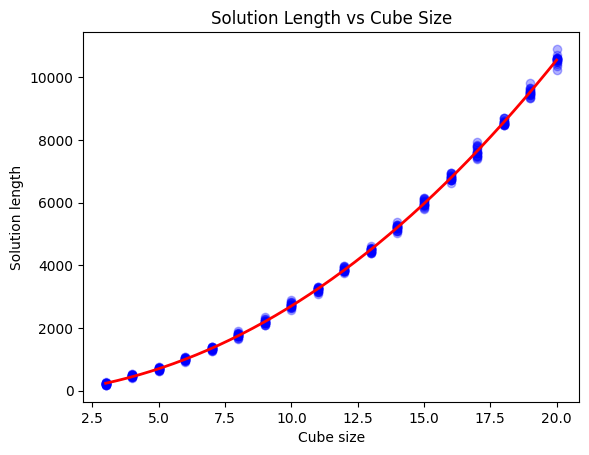

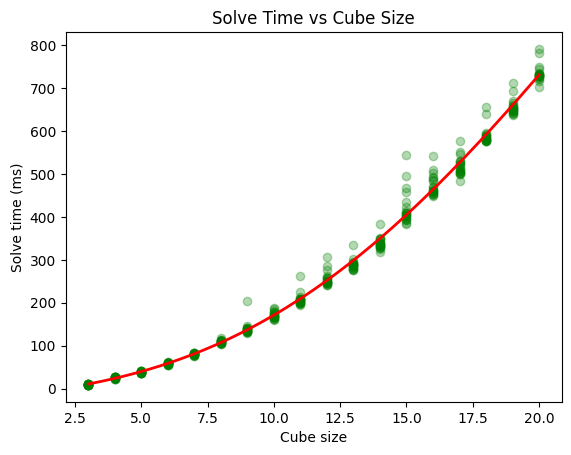

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from cube.cube import Cube
from cube.scramble import generate_scramble
from solvers.classic.classic_solver import ClassicSolver

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

sizes = list(range(3, 21))
all_sizes = []
all_lengths = []
all_times = []

for size in sizes:
    lengths = []
    times = []

    for seed in range(20):
        cube = Cube(size)
        scramble = generate_scramble(size, relative_length=1, seed=seed)
        cube.apply_sequence(scramble)
        solver = ClassicSolver(cube)

        start = time.perf_counter()
        solution = solver.solve()
        end = time.perf_counter()

        elapsed_ms = (end - start) * 1000  # convert to milliseconds
        lengths.append(len(solution))
        times.append(elapsed_ms)

        all_sizes.append(size)
        all_lengths.append(len(solution))
        all_times.append(elapsed_ms)

    avg_len = sum(lengths) / len(lengths)
    avg_time = sum(times) / len(times)
    print(f"Size {size}: length = {avg_len:.2f}, time = {avg_time:.2f} ms")

X_all = np.array(all_sizes).reshape(-1, 1)
y_lengths = np.array(all_lengths)
y_times = np.array(all_times)

length_model = make_pipeline(
    PolynomialFeatures(degree=5, include_bias=True),
    Ridge(alpha=1.0)
)
time_model = make_pipeline(
    PolynomialFeatures(degree=5, include_bias=True),
    Ridge(alpha=1.0)
)

length_model.fit(X_all, y_lengths)
time_model.fit(X_all, y_times)

def print_polynomial(model, name):
    ridge = model.named_steps["ridge"]
    coeffs = ridge.coef_
    intercept = ridge.intercept_
    terms = [f"{intercept:.2f}"]
    for i, c in enumerate(coeffs[1:], start=1):
        terms.append(f"{c:.2f}·x^{i}")
    print(f"\n{name} polynomial (degree 5):")
    print(" + ".join(terms))

print_polynomial(length_model, "Length")
print_polynomial(time_model, "Time (ms)")

x_plot = np.linspace(3, 20, 200).reshape(-1, 1)
y_len_plot = length_model.predict(x_plot)
y_time_plot = time_model.predict(x_plot)

plt.figure()
plt.scatter(all_sizes, all_lengths, color="blue", alpha=0.3)
plt.plot(x_plot, y_len_plot, color="red", linewidth=2)
plt.xlabel("Cube size")
plt.ylabel("Solution length")
plt.title("Solution Length vs Cube Size")
plt.show()

plt.figure()
plt.scatter(all_sizes, all_times, color="green", alpha=0.3)
plt.plot(x_plot, y_time_plot, color="red", linewidth=2)
plt.xlabel("Cube size")
plt.ylabel("Solve time (ms)")
plt.title("Solve Time vs Cube Size")
plt.show()